# MNIST Classifier — Analysis

Training now happens in `train.py`:

    uv run python projects/mnist/classifier/train.py

This notebook only loads the resulting checkpoint and metrics for analysis:
training curves, confusion matrix, per-class report, and translation
invariance.

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina', 'svg']
%load_ext autoreload
%autoreload 2

import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from chimera.data import MNISTDataModule
from chimera.models import DigitNet

RUN_DIR = "/mnt/ai/runs/mnist/classifier"
DATA_DIR = "/mnt/ai/data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 10
VARIANT = "tiny"

## Load checkpoint

In [4]:
ckpt = torch.load(
    f"{RUN_DIR}/checkpoints/classifier.ckpt", map_location="cpu", weights_only=False
)
model_state = {
    k.removeprefix("model."): v
    for k, v in ckpt["state_dict"].items()
    if k.startswith("model.")
}

model = DigitNet.from_variant(VARIANT, in_channels=1, num_classes=NUM_CLASSES)
model.load_state_dict(model_state)
model.to(DEVICE).eval()
print(
    f"loaded classifier ({sum(p.numel() for p in model.parameters()):,} params, epoch {ckpt['epoch']})"
)

loaded classifier (5,358 params, epoch 8)


In [5]:
dm = MNISTDataModule(data_dir=DATA_DIR)
dm.prepare_data()
dm.setup("test")
test_loader = dm.test_dataloader()

## Training curves

Reads the CSV log written alongside the wandb run (`chimera.utils.build_run_loggers`).

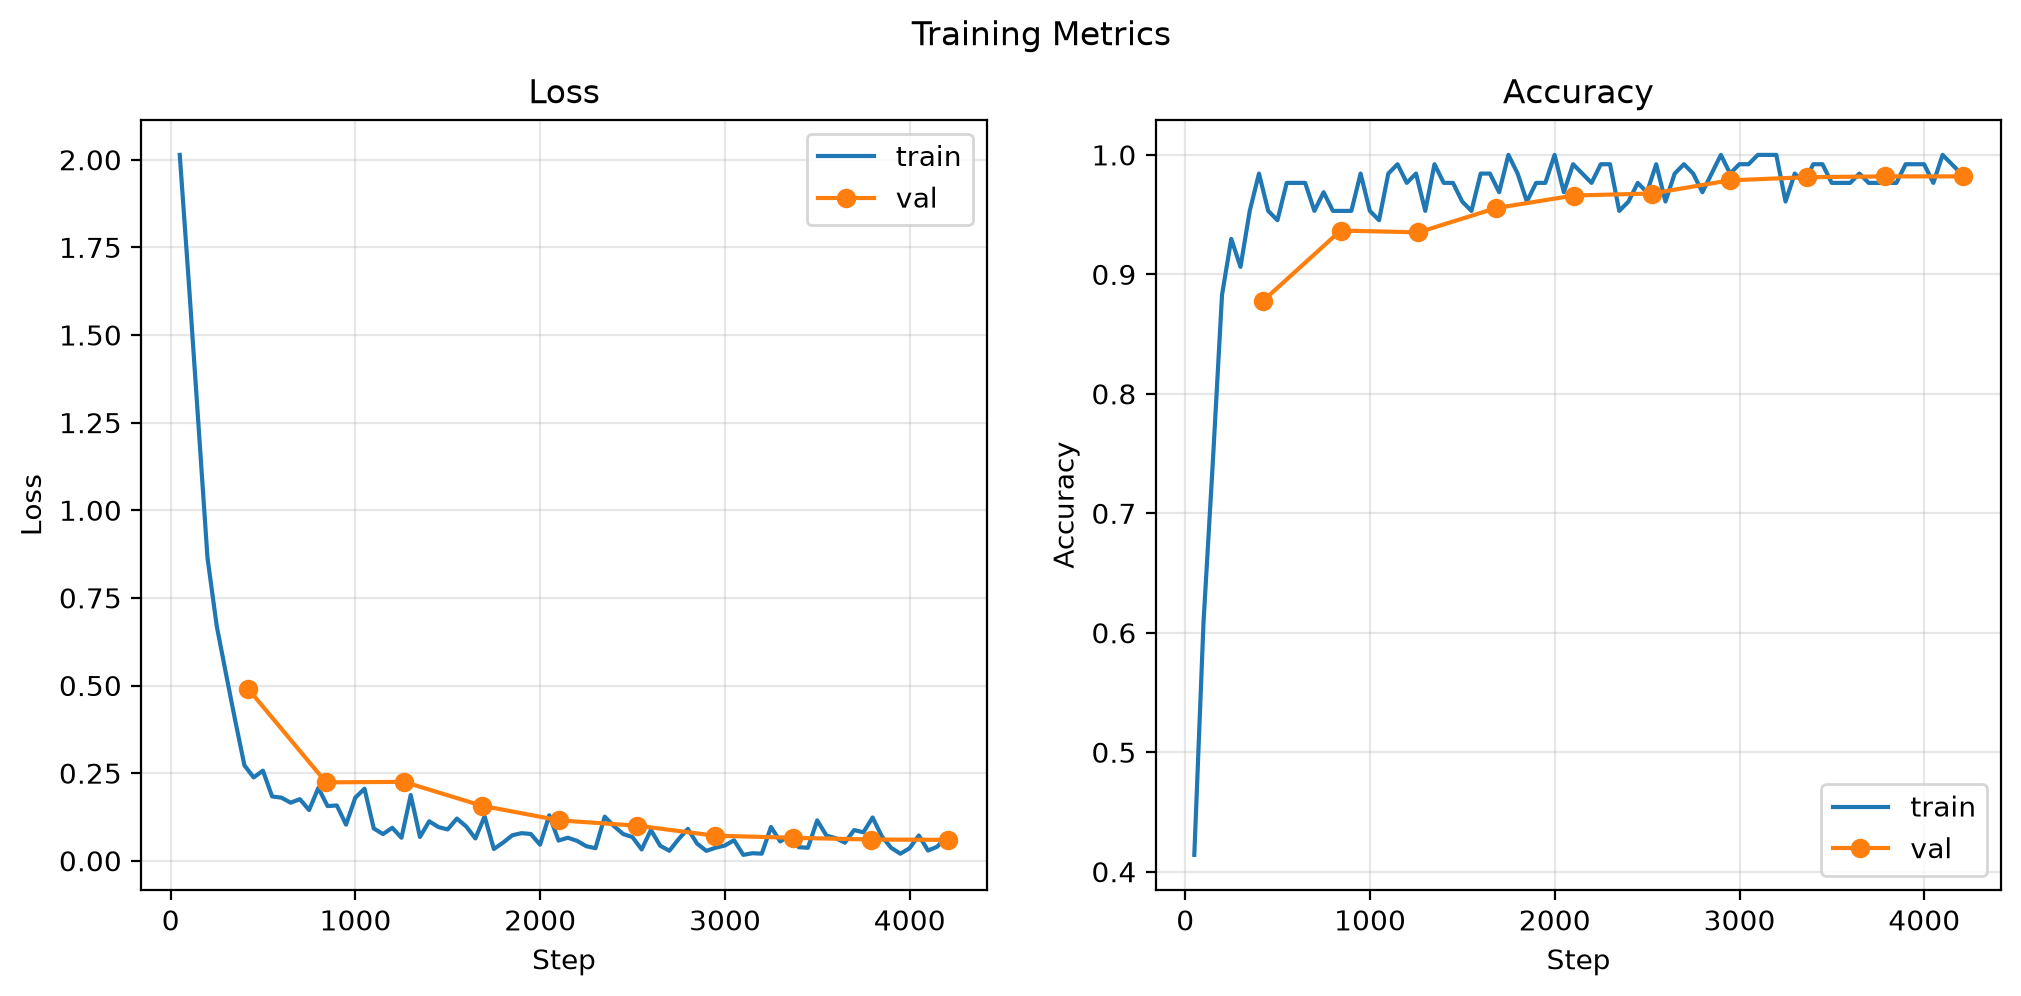

In [6]:
csv_path = sorted(glob.glob(f"{RUN_DIR}/csv/version_*/metrics.csv"))[-1]
metrics = pd.read_csv(csv_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Training Metrics")
for ax, key, title in zip(axes, ["loss", "acc"], ["Loss", "Accuracy"]):
    for stage in ["train", "val"]:
        col = f"{stage}/{key}"
        if col not in metrics.columns:
            continue
        d = metrics.dropna(subset=[col])
        ax.plot(d["step"], d[col], marker="o" if stage == "val" else None, label=stage)
    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)
plt.show()

## Confusion matrix + per-class report

(Also logged live during training as a wandb image + table — see `ClassifierModule.log_confusion_matrix`.)

Test accuracy: 0.9853

 class  precision     recall         f1  support
     0      0.981      0.988      0.984      980
     1      0.986      0.996      0.991     1135
     2      0.981      0.988      0.985     1032
     3      0.988      0.988      0.988     1010
     4      0.988      0.989      0.988      982
     5      0.982      0.982      0.982      892
     6      0.982      0.982      0.982      958
     7      0.985      0.986      0.986     1028
     8      0.991      0.975      0.983      974
     9      0.989      0.975      0.982     1009


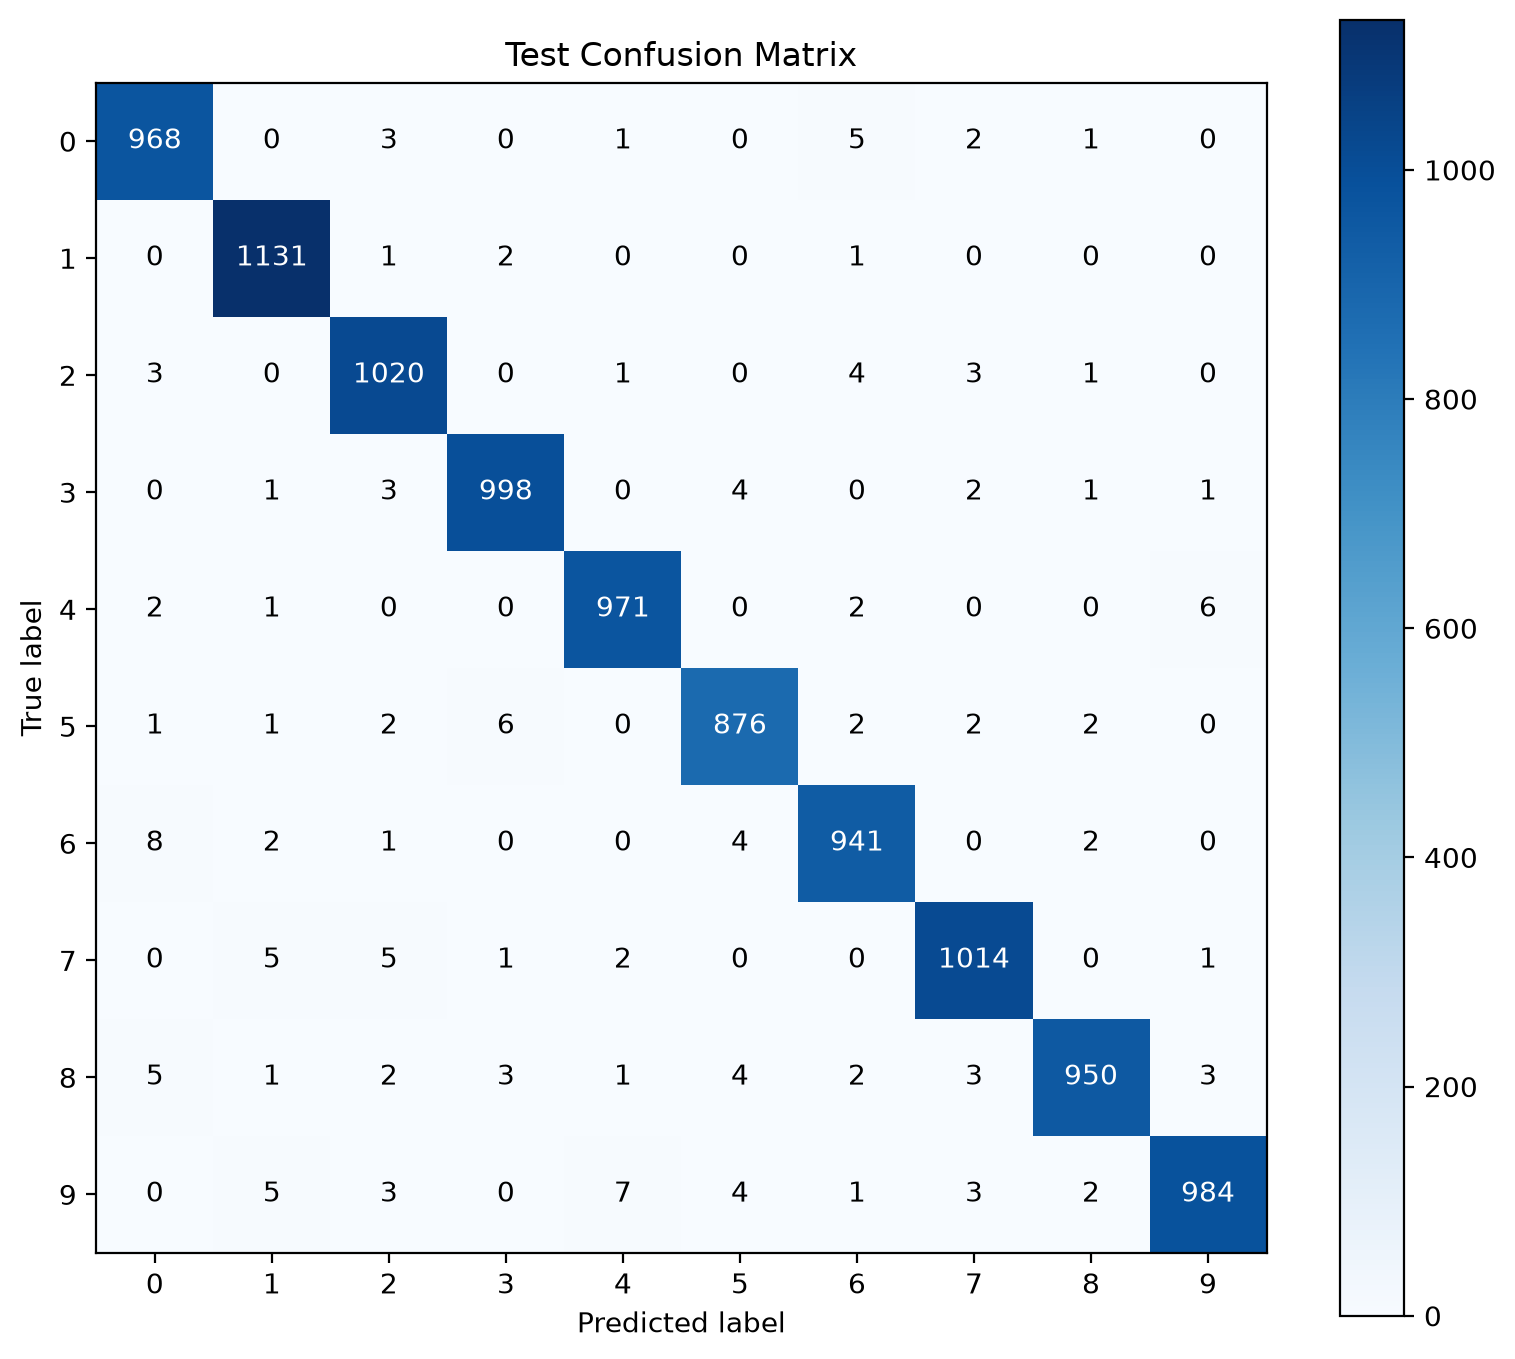

In [7]:
all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(DEVICE)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(y)
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
for t, p in zip(all_targets, all_preds):
    confusion[t, p] += 1

accuracy = confusion.diag().sum().item() / confusion.sum().item()
print(f"Test accuracy: {accuracy:.4f}\n")

support = confusion.sum(dim=1)
tp = confusion.diag()
precision = tp / confusion.sum(dim=0).clamp_min(1)
recall = tp / support.clamp_min(1)
f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-9)
print(f"{'class':>6}  {'precision':>9}  {'recall':>9}  {'f1':>9}  {'support':>7}")
for c in range(NUM_CLASSES):
    print(
        f"{c:>6}  {precision[c]:>9.3f}  {recall[c]:>9.3f}  {f1[c]:>9.3f}  {support[c]:>7d}"
    )

confusion_np = confusion.numpy()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(confusion_np, cmap="Blues")
fig.colorbar(im, ax=ax)
ax.set_title("Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
threshold = confusion_np.max() / 2
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(
            j,
            i,
            confusion_np[i, j],
            ha="center",
            va="center",
            color="white" if confusion_np[i, j] > threshold else "black",
        )
plt.tight_layout()
plt.show()

## Translation invariance

`DigitNet` is a LeNet-5: two avg-pools then a `flatten -> FC` head keyed to
absolute position. MNIST digits are centered, so the classifier never has to
learn shift tolerance — measure how quickly accuracy collapses off-center.

baseline accuracy (no shift): 0.985
  acc @ horizontal shift +1px: 0.983   (consistency 0.990)
  acc @ horizontal shift +2px: 0.982   (consistency 0.990)
  acc @ horizontal shift +3px: 0.979   (consistency 0.985)
  acc @ horizontal shift +4px: 0.973   (consistency 0.980)
  acc @ horizontal shift +6px: 0.926   (consistency 0.930)
  acc @ horizontal shift +8px: 0.795   (consistency 0.798)


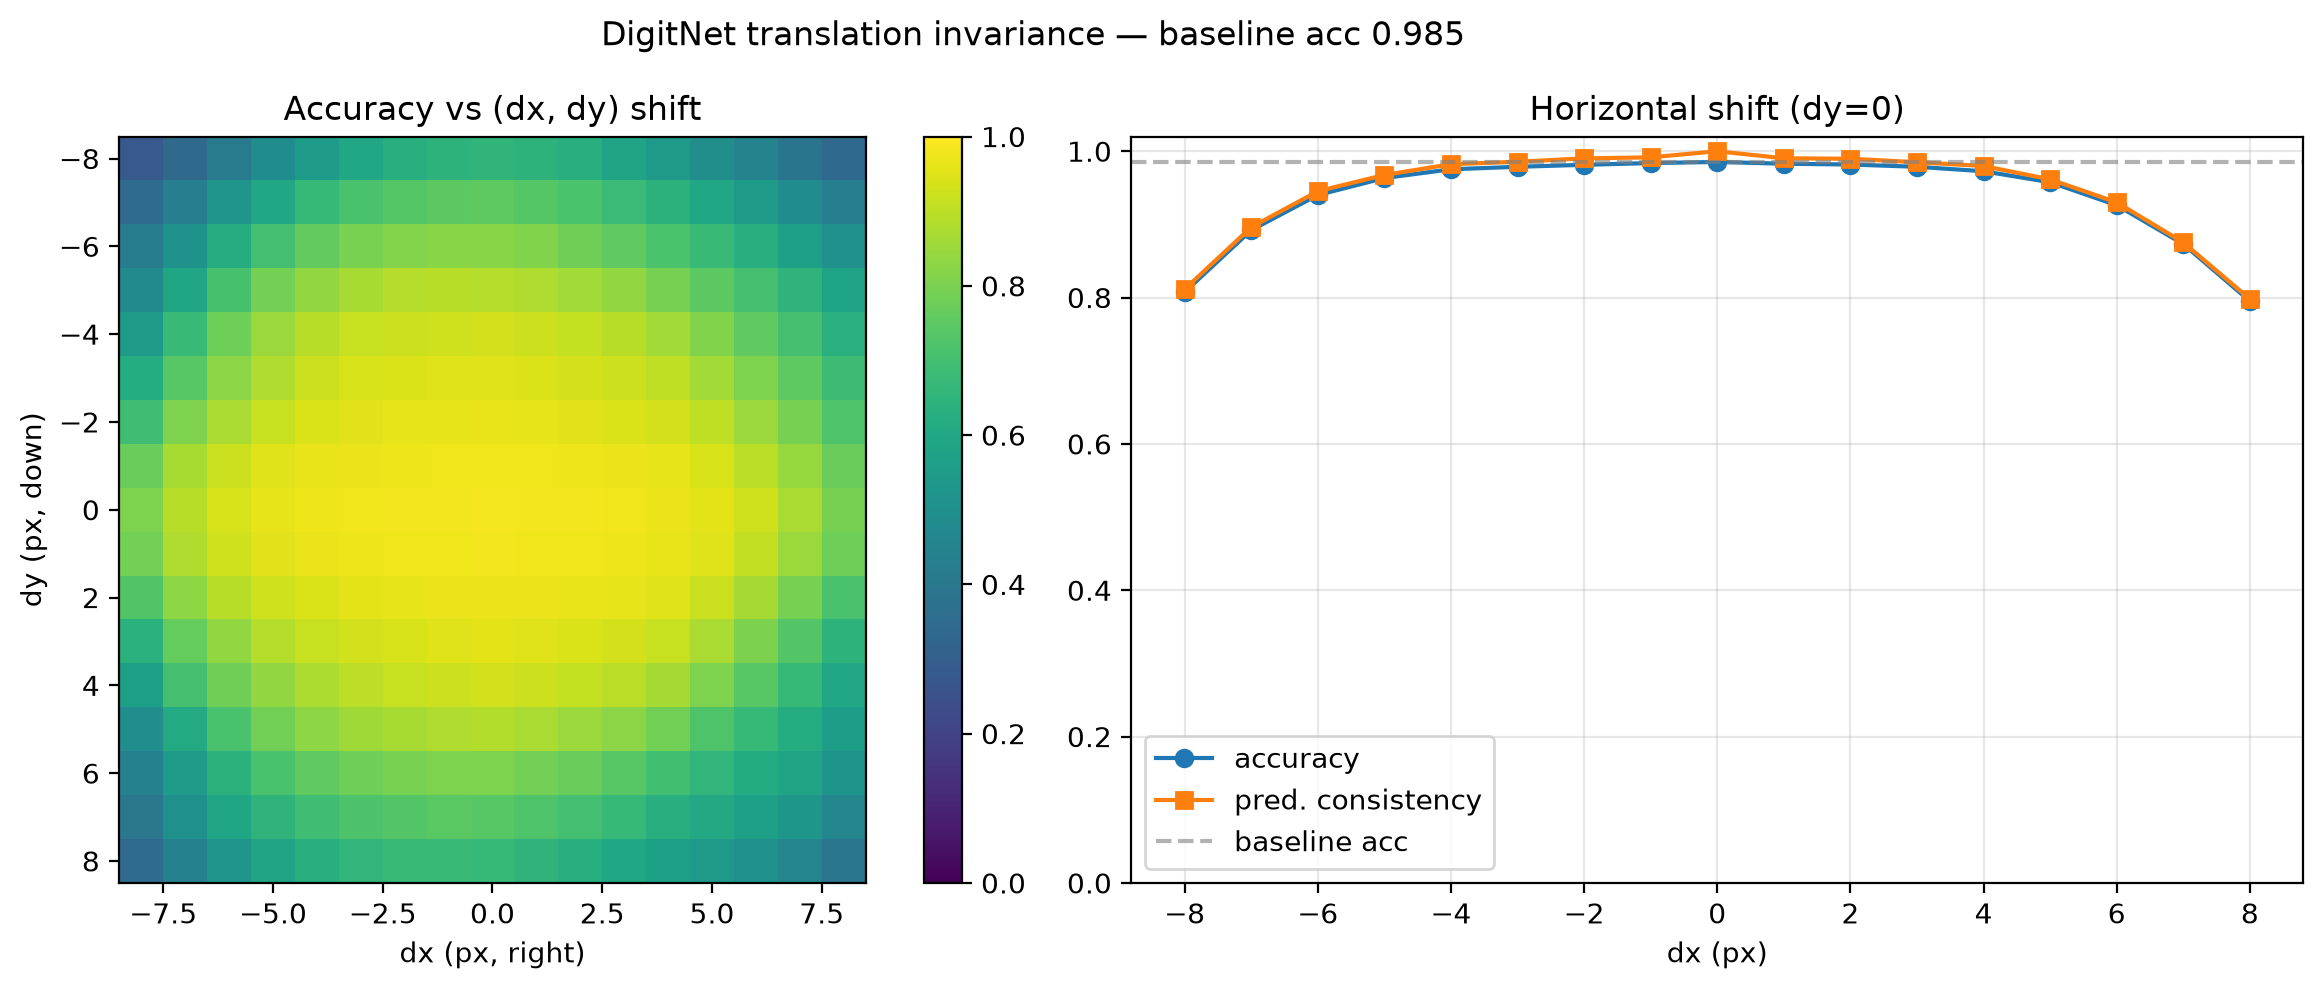

In [8]:
def shift_batch(x, dx, dy):
    """Shift (B, C, H, W) by dx (right) / dy (down) pixels, zero-filled."""
    out = torch.zeros_like(x)
    H, W = x.shape[-2:]
    sy, sx = slice(max(0, -dy), H - max(0, dy)), slice(max(0, -dx), W - max(0, dx))
    dys, dxs = slice(max(0, dy), H - max(0, -dy)), slice(max(0, dx), W - max(0, -dx))
    out[..., dys, dxs] = x[..., sy, sx]
    return out


@torch.no_grad()
def classifier_shift_sweep(model, loader, shifts, device):
    x_all, y_all = [], []
    for x, y in loader:
        x_all.append(x)
        y_all.append(y)
    x_all = torch.cat(x_all).to(device)
    y_all = torch.cat(y_all).to(device)

    base_pred = model(x_all).argmax(1)
    base_acc = (base_pred == y_all).float().mean().item()

    acc = np.zeros((len(shifts), len(shifts)))
    cons = np.zeros((len(shifts), len(shifts)))
    for i, dy in enumerate(shifts):
        for j, dx in enumerate(shifts):
            pred = model(shift_batch(x_all, dx, dy)).argmax(1)
            acc[i, j] = (pred == y_all).float().mean().item()
            cons[i, j] = (pred == base_pred).float().mean().item()
    return base_acc, acc, cons


shifts = list(range(-8, 9, 1))
center = shifts.index(0)
base_acc, shift_acc, shift_cons = classifier_shift_sweep(
    model, test_loader, shifts, DEVICE
)

print(f"baseline accuracy (no shift): {base_acc:.3f}")
for s in [1, 2, 3, 4, 6, 8]:
    print(
        f"  acc @ horizontal shift +{s}px: {shift_acc[center, center + s]:.3f}"
        f"   (consistency {shift_cons[center, center + s]:.3f})"
    )

extent = [shifts[0] - 0.5, shifts[-1] + 0.5, shifts[-1] + 0.5, shifts[0] - 0.5]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"DigitNet translation invariance — baseline acc {base_acc:.3f}")
im = axes[0].imshow(shift_acc, cmap="viridis", extent=extent, vmin=0, vmax=1)
axes[0].set_title("Accuracy vs (dx, dy) shift")
axes[0].set_xlabel("dx (px, right)")
axes[0].set_ylabel("dy (px, down)")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].plot(shifts, shift_acc[center], marker="o", label="accuracy")
axes[1].plot(shifts, shift_cons[center], marker="s", label="pred. consistency")
axes[1].axhline(base_acc, ls="--", c="gray", alpha=0.6, label="baseline acc")
axes[1].set_title("Horizontal shift (dy=0)")
axes[1].set_xlabel("dx (px)")
axes[1].set_ylim(0, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()